In [179]:
#Imports
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.core.common import random_state
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV



In [180]:
#Load data 
df = sns.load_dataset('titanic')

# 1. Data exploration


In [181]:
# Basic Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


Now this is the tables and which have null values, the embarked column is almost completely full, age is missing around a quarter , and deck has around only a quarter of entries with the rest of null.

In [182]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Above is the statisitcs of the numerical and continuous data, such as Q1, Q2, Q3. We can also notice that magnitudes of the features are not scaled the same. 

In [183]:
# Passenger class
df['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

Passenger Class a majority being class 3. Look at the visualization below for better comprehension.

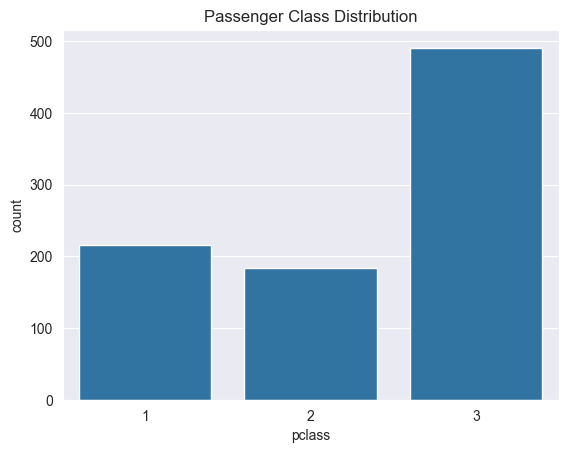

In [184]:
# Passenger class distribution
sns.countplot(x='pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()


In [185]:
# Survived Class
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

Survived Class illustrates that 549 of 891 (61.6%) did not survive based on the raw data.

In [186]:
# Sex distribution 
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In terms of Sex, 577 of the 891 are male (64%), illustrating a majority were male passengers from the survey

In [187]:
# Survived By class
pd.crosstab(df['pclass'], df['survived'], margins=True)

survived,0,1,All
pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


As we can see here, class 1 majority survived (62.9%), class 2 a little less than half survived (47.2%), and in class 3 a minority survived (24.2%) around a quarter. Look at the viualization below

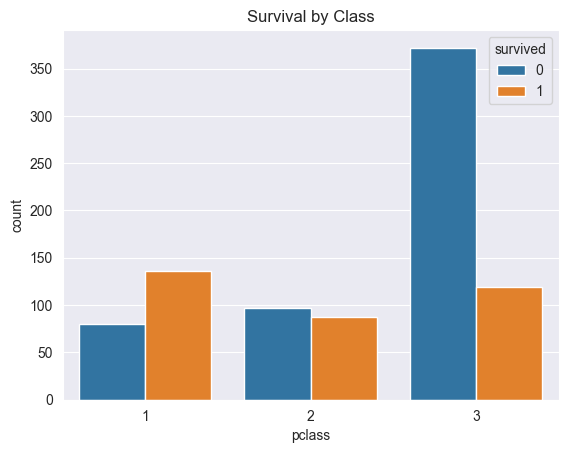

In [188]:
# Survival by class
sns.countplot(x='pclass', hue='survived', data=df)
plt.title('Survival by Class')
plt.show()

## Based on our research so far
- 4 of the features are binary classifiers, 5 including the survived taget classification.
- The lower the class number is the higher the chance the passenger survived.
- Class 3 are the majority population.
- Some classes were made as numerical values where they could have been categorical.

# 2. Data Preprocessing

## Handling the Missing values

In [189]:
# Median imputation for age
df['age'] = df['age'].fillna(df['age'].median())

# Mode filling for embarked
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Drop deck (too many missing values) it would be just fabricating data if we continue to maintain it.
df.drop(columns=['deck'], inplace=True)

Age, just use median, for embarked use mode, and just drop deck to make sure we are not making our own data and skewing the results.

## Encoding Categorical Features

In [190]:

# Label encode sex (male=1, female=0)
labelEncoder = LabelEncoder()
df['sex'] = labelEncoder.fit_transform(df['sex'])

# One hot encoding for embarked
df = pd.get_dummies(df, columns=['embarked'], drop_first=False)

## Standardize Numerical Features

In [191]:
scaler = StandardScaler()
# We have chosen to use standard scalar because it helps SVM predictors since points are always roughly ditributed around a center
numericColumns = ['age', 'fare', 'sibsp', 'parch']
df[numericColumns] = scaler.fit_transform(df[numericColumns])

## Assert Data is adjusted

In [192]:
# Current data set data after updates
df.info()
# Sample data
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    float64 
 5   parch        891 non-null    float64 
 6   fare         891 non-null    float64 
 7   class        891 non-null    category
 8   who          891 non-null    str     
 9   adult_male   891 non-null    bool    
 10  embark_town  889 non-null    str     
 11  alive        891 non-null    str     
 12  alone        891 non-null    bool    
 13  embarked_C   891 non-null    bool    
 14  embarked_Q   891 non-null    bool    
 15  embarked_S   891 non-null    bool    
dtypes: bool(5), category(1), float64(4), int64(3), str(3)
memory usage: 75.1 KB


,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,embarked_C,embarked_Q,embarked_S
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,Third,man,True,Southampton,no,False,False,False,True
1,1,1,0,0.663861,0.432793,-0.473674,0.786845,First,woman,False,Cherbourg,yes,False,True,False,False
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,Third,man,True,Southampton,no,True,False,False,True


As we can see the nulls have been addressed and encodings have been adjusted

# 3. Feature Selection


## Correlation Heatmap

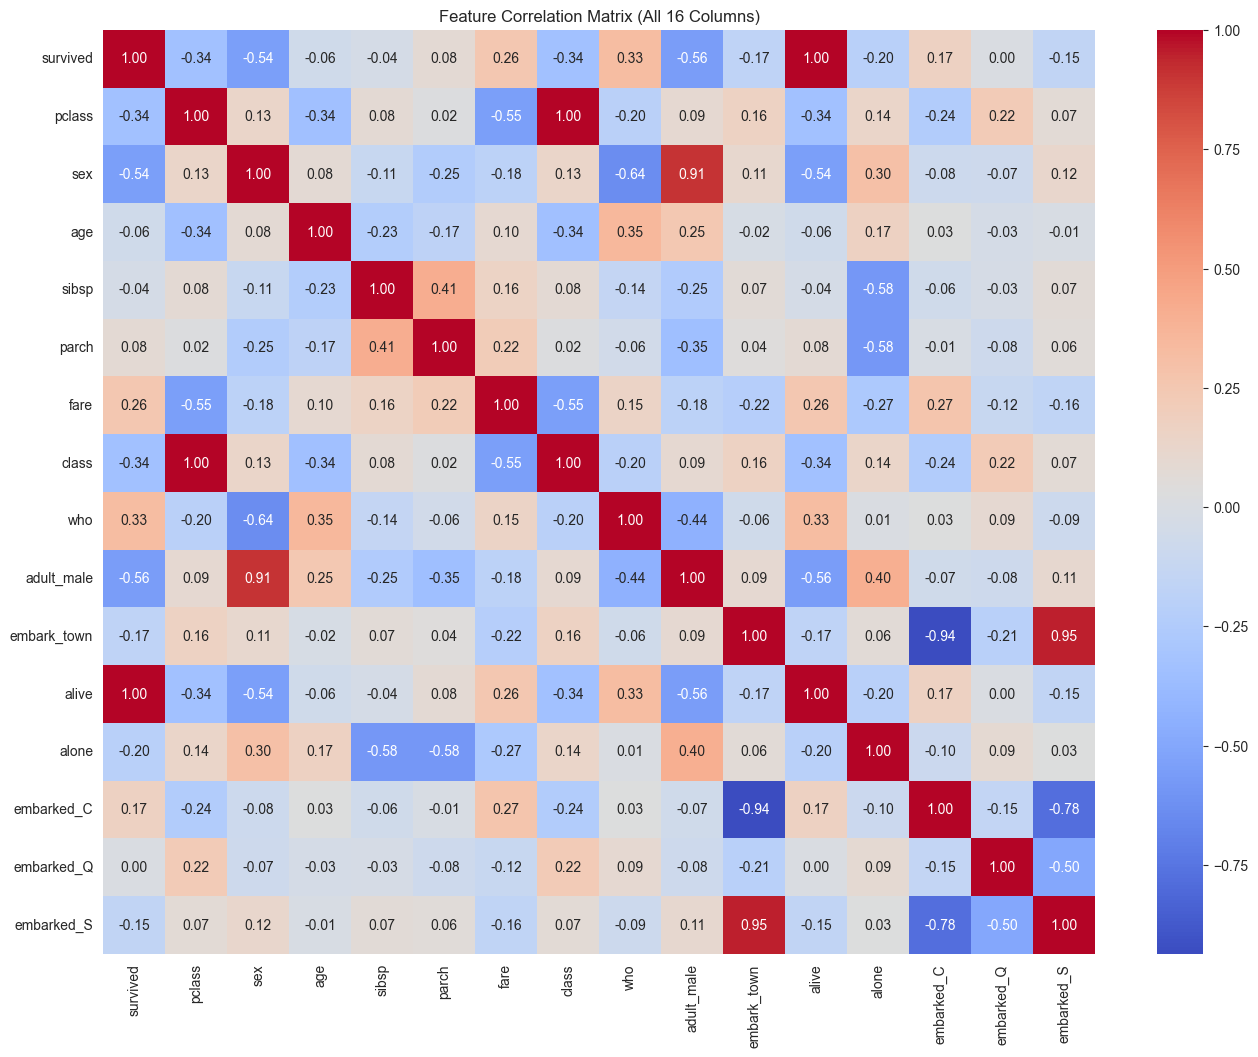

In [193]:
  df_viz = df.copy() # we do not want to change the existing data.
  df_viz['alive'] = df_viz['alive'].map({'yes': 1, 'no': 0})
  df_viz['class'] = df_viz['class'].map({'First': 1, 'Second': 2, 'Third': 3})
  # encode (man/woman/child → 0/1/2)
  df_viz['who'] = LabelEncoder().fit_transform(df_viz['who'])
  df_viz['embark_town'] = LabelEncoder().fit_transform(df_viz['embark_town'].fillna(df_viz['embark_town'].mode()[0]))

  plt.figure(figsize=(16, 12))
  sns.heatmap(df_viz.corr(), annot=True, fmt='.2f', cmap='coolwarm')
  plt.title('Feature Correlation Matrix (All 16 Columns)')
  plt.show()

As you can see we had to make a temp data source and changes some encodings to numeric values in order to make a proper correlation map and see what features are correlated.
The features that are showing redundancy or high correlation are:
- alive and survided (obviously they are the same thing just different encodings)
- class and pclass (same thing just different encodings)
- adult_male and sex (since adult_male is just a subset of sex, it is redundant)

As well as the derived features from other columns alone such as:
- alone -> same data could be concluded from the sibsp and parch columns, since alone is just a binary classifier of whether the sum of those two columns is 0 or not.


In [194]:
df.drop(columns=['class', 'alive', 'who', 'adult_male', 'embark_town', 'alone'], inplace=True)

This leaves us with 10 columns after the correlation check with the heatmap check

## Information Gain Check
Lets see what features have the highest information gain with respect to the target variable (survived)

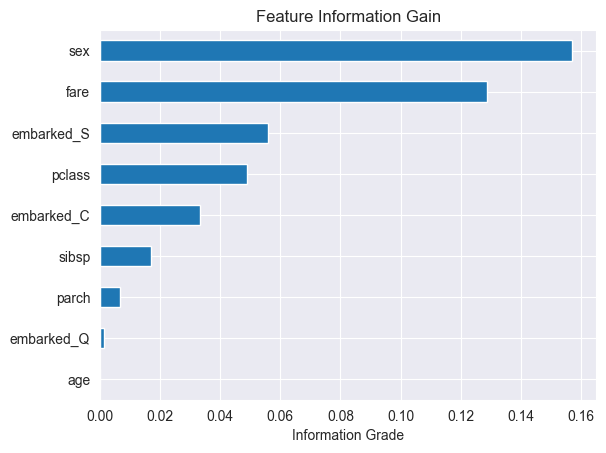

In [195]:
x = df.drop(columns=['survived'])
y = df['survived']

info_gain = pd.Series(mutual_info_classif(x, y, random_state=42), index=x.columns).sort_values()
info_gain.describe()
info_gain.plot(kind='barh')
plt.title('Feature Information Gain')
plt.xlabel('Information Grade')
plt.show()

As we can see the features with the highest information gain are:
- Sex
- Fare

Also keep in mind, embarked_q gives us minute information gain which I do expect to be true, as it is a subset of some data.

**However,**

even though age has a low information gain, I am speculative this could be artificial due to the fact that in reality it would have made sense that women and children had a higher chance of survival, but since we have imputed the age data with the median, it is possible that the information gain is not reflecting the true value of the feature that may come in the future.


In [196]:
df.drop(columns=['embarked_Q'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    int64  
 3   age         891 non-null    float64
 4   sibsp       891 non-null    float64
 5   parch       891 non-null    float64
 6   fare        891 non-null    float64
 7   embarked_C  891 non-null    bool   
 8   embarked_S  891 non-null    bool   
dtypes: bool(2), float64(4), int64(3)
memory usage: 50.6 KB


# 4. Data Division
We will be dividing the data into training/validating/testing sets with a 5 fold cross validation. I used this technique to ensure we are ensuring the best use for our data.


In [197]:
# Making the KFolds
x = df.drop(columns=['survived'])
y = df['survived']

# stratified means that each fold has the same survived ratio as the normal data to make sure we are not skewing the data. We also add shuffle parameter to ensure that the data is not affected by sorted data.
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Model Building

## SVM

### Tuning The Kernel

In [198]:
#Tuning the Kernel

svmModel = SVC(kernel="linear", random_state=42)
svmScores = cross_val_score(svmModel, x, y, cv=stratifiedKFold, scoring='accuracy')
print(f'SVM Linear Kernel Accuracy Scores: {svmScores}')
print(f'Mean Linear Kernel Accuracy: {svmScores.mean():.4f} (+/- {svmScores.std():.4f})')

svmModel = SVC(kernel="rbf", random_state=42)
svmScores = cross_val_score(svmModel, x, y, cv=stratifiedKFold, scoring='accuracy')
print(f'SVM RBF Kernel Accuracy Scores: {svmScores}')
print(f'Mean RBF Kernel Accuracy: {svmScores.mean():.4f} (+/- {svmScores.std():.4f})')

SVM Linear Kernel Accuracy Scores: [0.7877095  0.7752809  0.78651685 0.76404494 0.82022472]
Mean Linear Kernel Accuracy: 0.7868 (+/- 0.0188)
SVM RBF Kernel Accuracy Scores: [0.84916201 0.80337079 0.80898876 0.82022472 0.84831461]
Mean RBF Kernel Accuracy: 0.8260 (+/- 0.0193)


After running the model training on the SVM with both linear and rbf kernels, we can see that the rbf kernel is performing better than the linear kernel, which indicates that the data is not linearly separable.

### Tuning the C parameter

In [199]:
# Tuning the C parameter for the RBF kernel
cValues = {'C' : [0.01, 0.1, 1, 10, 100]}
svm_grid = GridSearchCV(SVC(kernel='rbf', random_state=42), cValues, cv=stratifiedKFold, scoring='accuracy')
svm_grid.fit(x, y)
print(f'Best RBF C parameter: {svm_grid.best_params_}')
print(f'Best RBF Kernel Accuracy: {svm_grid.best_score_:.4f}')

#Tuning the C parameter for the Linear kernel
cValues = {'C' : [0.01, 0.1, 1, 10, 100]}
svm_grid = GridSearchCV(SVC(kernel='linear', random_state=42), cValues, cv=stratifiedKFold, scoring='accuracy')
svm_grid.fit(x, y)
print(f'Best Linear C parameter: {svm_grid.best_params_}')
print(f'Best Linear Kernel Accuracy: {svm_grid.best_score_:.4f}')

Best RBF C parameter: {'C': 1}
Best RBF Kernel Accuracy: 0.8260
Best Linear C parameter: {'C': 0.1}
Best Linear Kernel Accuracy: 0.7868


After tuning the C we are seeing that the best C for the RBF kernel is 1, although with this range we haven't increased the accuracy much, it is still worth exploring.

### Tuning the gamma parameter

In [200]:
parameters = {
    'kernel': ['rbf', 'linear'],
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100],
}
svm_grid = GridSearchCV(SVC(random_state=42), parameters, cv=stratifiedKFold, scoring='accuracy')
svm_grid.fit(x, y)
print(f'Best SVM parameters: {svm_grid.best_params_}')
print(f'Best SVM Accuracy: {svm_grid.best_score_:.4f}')

Best SVM parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best SVM Accuracy: 0.8249


After tuning all parameters, we are seeing that the best parameters for the SVM model are C=1, gamma=0.001, and kernel=rbf, which gives us an accuracy of 82%.

## Random Forest


In [201]:
randomForestModel = RandomForestClassifier(n_estimators=100, random_state=42)
randomForestScores = cross_val_score(randomForestModel, x, y, cv=stratifiedKFold, scoring='accuracy')
print(f"Random Forest Accuracy Scores: {randomForestScores}")
print(f'Mean Accuracy: {randomForestScores.mean():.4f} (+/- {randomForestScores.std():.4f})')


Random Forest Accuracy Scores: [0.83798883 0.80898876 0.79213483 0.8258427  0.84269663]
Mean Accuracy: 0.8215 (+/- 0.0188)
